In [24]:
# ==============================================
# TRABALHO 1 - TRATAMENTO DE DADOS HIDROLÓGICOS
# ==============================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import chi2
from sklearn.covariance import EllipticEnvelope
from sklearn.preprocessing import MinMaxScaler
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
dfJ = pd.read_csv('/content/drive/My Drive/IA/Trabalho 1 - IA/Estações Joinville/Estação Joinville RVPSC-2648014.csv')
dfI = pd.read_csv('/content/drive/My Drive/IA/Trabalho 1 - IA/Estações Joinville/Estação Itapocu 2648020.csv')
dfP = pd.read_csv('/content/drive/My Drive/IA/Trabalho 1 - IA/Estações Joinville/Estação Ponte SC-301 2648028.csv')

In [26]:
# ==========================
# LEITURA E ANÁLISE INICIAL
# ==========================
print("\nDimensão do banco:", dfJ.shape)
print("\nColunas:", dfJ.columns[:10])
print("\nValores nulos por coluna:\n", dfJ.isnull().sum().sort_values(ascending=False).head(10))



Dimensão do banco: (1656, 75)

Colunas: Index(['EstacaoCodigo', 'NivelConsistencia', 'Data', 'TipoMedicaoChuvas',
       'Maxima', 'Total', 'DiaMaxima', 'NumDiasDeChuva', 'MaximaStatus',
       'TotalStatus'],
      dtype='object')

Valores nulos por coluna:
 Chuva31           729
TotalAnual        396
Chuva30           203
Chuva29           170
NumDiasDeChuva    153
Maxima            146
DiaMaxima         146
Chuva19            94
Chuva07            93
Chuva12            92
dtype: int64


In [27]:
print("\nDimensão do banco:", dfI.shape)
print("\nColunas:", dfI.columns[:10])
print("\nValores nulos por coluna:\n", dfI.isnull().sum().sort_values(ascending=False).head(10))


Dimensão do banco: (898, 75)

Colunas: Index(['EstacaoCodigo', 'NivelConsistencia', 'Data', 'TipoMedicaoChuvas',
       'Maxima', 'Total', 'DiaMaxima', 'NumDiasDeChuva', 'MaximaStatus',
       'TotalStatus'],
      dtype='object')

Valores nulos por coluna:
 Chuva31           384
TotalAnual        370
Chuva30            87
Chuva29            69
NumDiasDeChuva     32
Maxima             28
DiaMaxima          28
Chuva11            18
Chuva02            17
Chuva15            17
dtype: int64


In [28]:
print("\nDimensão do banco:", dfP.shape)
print("\nColunas:", dfP.columns[:10])
print("\nValores nulos por coluna:\n", dfP.isnull().sum().sort_values(ascending=False).head(10))


Dimensão do banco: (830, 75)

Colunas: Index(['EstacaoCodigo', 'NivelConsistencia', 'Data', 'TipoMedicaoChuvas',
       'Maxima', 'Total', 'DiaMaxima', 'NumDiasDeChuva', 'MaximaStatus',
       'TotalStatus'],
      dtype='object')

Valores nulos por coluna:
 TotalAnual        374
Chuva31           352
NumDiasDeChuva     87
Chuva30            76
Chuva29            60
Maxima             40
DiaMaxima          40
Total              20
Chuva24            15
Chuva16            15
dtype: int64


In [29]:
for df in (dfJ, dfI, dfP):
    # Data como datetime e ordena
    if 'Data' in df.columns:
        df['Data'] = pd.to_datetime(df['Data'], errors='coerce')
        df.sort_values('Data', inplace=True)

In [30]:
# Excluir colunas com 'Chuva' e 'Status' no nome
def drop_status_cols(d):
    status_cols = [c for c in d.columns if 'Status' in c]
    return d.drop(columns=status_cols)

dfJ_s = drop_status_cols(dfJ)
dfI_s = drop_status_cols(dfI)
dfP_s = drop_status_cols(dfP)

In [31]:
# ===============================
# TRATAMENTO DE VALORES AUSENTES
# ===============================
dfJ_f = dfJ_s.ffill().bfill()
dfI_f = dfI_s.ffill().bfill()
dfP_f = dfP_s.ffill().bfill()

print("\nDados após tratamento:")
print(dfJ_f.isnull().sum().sum(), "valores ausentes restantes.")
print(dfI_f.isnull().sum().sum(), "valores ausentes restantes.")
print(dfP_f.isnull().sum().sum(), "valores ausentes restantes.")


Dados após tratamento:
0 valores ausentes restantes.
0 valores ausentes restantes.
0 valores ausentes restantes.


In [32]:
# ================================
# SELEÇÃO DE VARIÁVEIS RELEVANTES
# ================================

# Seleciona apenas variáveis numéricas
df1_num = df1.select_dtypes(include=[np.number])

# Analisando principais variáveis de precipitação
colunas_principais = ['Maxima', 'Total', 'NumDiasDeChuva']
df_teste = df1_num[colunas_principais].copy()
df_teste = df_teste.dropna()


In [33]:
# -------------------------
# TESTE DE p-values (Chi²)
# -------------------------
# Cria um alvo binário simples: 1 se Total > mediana; 0 caso contrário
use_cols = ['Maxima', 'Total', 'NumDiasDeChuva']  # ajusta se faltar algo
df_teste = df1[[c for c in use_cols if c in df1.columns]].dropna().copy()

# alvo (categoria “chuvoso”)
med = df_teste['Total'].median()
df_teste['Categoria'] = (df_teste['Total'] > med).astype(int)

# Chi² (requer não-negativos)
from sklearn.feature_selection import chi2
X = df_teste[['Maxima','NumDiasDeChuva']].clip(lower=0)  # evita valores negativos
y = df_teste['Categoria']

chi_vals, p_vals = chi2(X, y)
rank_chi = (pd.DataFrame({'Chi2': chi_vals, 'p-Value': p_vals}, index=X.columns)
            .sort_values('Chi2', ascending=False))
print("\n--- Chi² (Joinville) ---")
print(rank_chi)
print("Obs.: p < 0.05 => associação significativa.")


--- Chi² (Joinville) ---
                        Chi2        p-Value
Maxima          10695.474275   0.000000e+00
NumDiasDeChuva   1148.820708  8.094494e-252
Obs.: p < 0.05 => associação significativa.


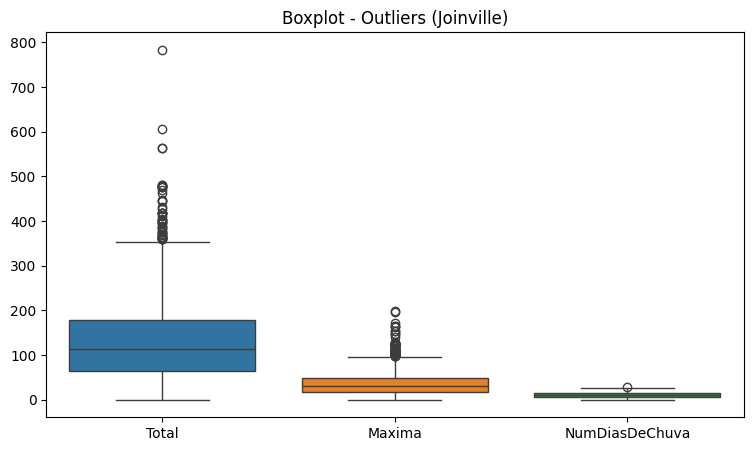


--- EllipticEnvelope ---
Outliers detectados: 166
Amostras válidas: 1490


In [34]:
# ----------
# OUTLIERS
# ----------
# 1 Boxplot simples
import seaborn as sns, matplotlib.pyplot as plt
plt.figure(figsize=(9,5))
sns.boxplot(data=df_teste[['Total','Maxima','NumDiasDeChuva']])
plt.title('Boxplot - Outliers (Joinville)')
plt.show()

# 2 Elliptic Envelope multivariado
from sklearn.covariance import EllipticEnvelope
ee_cols = ['Maxima','Total','NumDiasDeChuva']
Xee = df_teste[ee_cols].dropna()
out_mask = EllipticEnvelope(contamination=0.10).fit_predict(Xee) == 1
dados = Xee.loc[out_mask]
print("\n--- EllipticEnvelope ---")
print("Outliers detectados:", (~out_mask).sum())
print("Amostras válidas:", dados.shape[0])


In [35]:
def chi2_e_outlier(df_station, nome=''):
    cols = ['Maxima','Total','NumDiasDeChuva']
    base = df_station[[c for c in cols if c in df_station.columns]].dropna().copy()
    if 'Total' not in base.columns:
        print(f"{nome}: sem 'Total' pra alvo."); return
    med = base['Total'].median()
    base['Categoria'] = (base['Total'] > med).astype(int)

    X = base[['Maxima','NumDiasDeChuva']].clip(lower=0)
    y = base['Categoria']
    chi_vals, p_vals = chi2(X, y)
    print(f"\n--- Chi² ({nome}) ---")
    print(pd.DataFrame({'Chi2': chi_vals, 'p-Value': p_vals}, index=X.columns)
            .sort_values('Chi2', ascending=False))

    from sklearn.covariance import EllipticEnvelope
    Xee = base[['Maxima','Total','NumDiasDeChuva']].dropna()
    mask = EllipticEnvelope(contamination=0.10).fit_predict(Xee) == 1
    print(f"({nome}) outliers:", (~mask).sum(), "| válidos:", mask.sum())

chi2_e_outlier(df2, 'Itapocu')
chi2_e_outlier(df3, 'Ponte SC-301')


--- Chi² (Itapocu) ---
                       Chi2        p-Value
Maxima          9558.898347   0.000000e+00
NumDiasDeChuva   514.911798  5.414495e-114
(Itapocu) outliers: 90 | válidos: 808

--- Chi² (Ponte SC-301) ---
                       Chi2       p-Value
Maxima          5603.033216  0.000000e+00
NumDiasDeChuva   404.062140  7.189007e-90
(Ponte SC-301) outliers: 84 | válidos: 746


In [36]:
# =============
# NORMALIZAÇÃO
# =============

scaler = MinMaxScaler()
norm = pd.DataFrame(scaler.fit_transform(dados), columns=ee_cols)
print("\nHead normalizado:")
print(norm.head())


Head normalizado:
   Maxima     Total  NumDiasDeChuva
0   0.763  0.459712        0.259259
1   0.763  0.459712        0.259259
2   0.313  0.538954        0.703704
3   0.313  0.538954        0.703704
4   0.172  0.250000        0.333333
